# Simplified CoLES / GRU Contrastive Encoder для получения клиентских эмбеддингов

Этот ноутбук — шаблон, который можно адаптировать под свои финансовые/транзакционные данные.

**Цель:**  
из таблицы транзакций получить фиксированный embedding для каждого клиента:

```text
raw transactions → client sequences → random slices → GRU encoder → contrastive training → final client embeddings
```

Ожидаемый формат исходных данных:

```text
client_id | datetime | amount | category/MCC | transaction_type | ...
```

Минимально нужны:
- `client_id`
- `datetime`
- `amount`
- `category` или `mcc`

Если названия колонок у тебя другие, поменяй их в секции **Configuration**.

## 0. SET-UP

In [1]:
import os
import random
import pickle
from pathlib import Path

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

## 1. Configuration

В этой секции нужно указать:
- путь к файлу с транзакциями;
- названия колонок;
- параметры последовательностей;
- параметры модели и обучения.

Поменяй значения под свой датасет.

In [2]:
# =========================
# Paths
# =========================

OUTPUT_DIR = Path("outputs_embeddings")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# =========================
# Column names
# =========================

CLIENT_COL = "cl_id"
DATETIME_COL = "TRDATETIME"
AMOUNT_COL = "amount"

CATEGORY_COL = "MCC"
TYPE_COL = "trx_category"

EXTRA_CAT_COLS = ["channel_type", "currency"]
# =========================
# Sequence settings
# =========================

MIN_CLIENT_TX = 20       # минимальное число транзакций на клиента
MAX_FULL_SEQ_LEN = 300   # сколько транзакций брать для финального embedding
MIN_SLICE_LEN = 20       # минимальная длина среза для contrastive training
MAX_SLICE_LEN = 120      # максимальная длина среза

# =========================
# Model settings
# =========================

CATEGORY_EMB_DIM = 32
TYPE_EMB_DIM = 8
EXTRA_CAT_EMB_DIM = 8
NUM_PROJ_DIM = 16

EVENT_HIDDEN_DIM = 64
GRU_HIDDEN_DIM = 128
CLIENT_EMB_DIM = 128

DROPOUT = 0.1

# =========================
# Training settings
# =========================

BATCH_SIZE = 128
NUM_EPOCHS = 15
LR = 1e-3
WEIGHT_DECAY = 1e-5
TEMPERATURE = 0.07

RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

Device: cpu


## 2. Загрузка данных

Здесь загружаем таблицу с транзакциями и смотрим базовую информацию:
- сколько строк;
- сколько клиентов;
- какие колонки;
- есть ли пропуски.

Если у тебя parquet, замени `pd.read_csv` на `pd.read_parquet`.

In [50]:
train = pd.read_csv("hf://datasets/pytorch-lifestream/rosbank-churn/train.csv.gz")
test = pd.read_csv("hf://datasets/pytorch-lifestream/rosbank-churn/test.csv.gz")

In [4]:
test

,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category
0,01/04/2017,2,5814,NaN,810,18APR17:00:00:00,153.00,POS
1,01/03/2017,2,5812,NaN,810,10MAR17:00:00:00,388.08,POS
2,01/02/2017,2,5691,NaN,810,21FEB17:00:00:00,999.00,POS
3,01/04/2017,2,5814,NaN,810,26APR17:00:00:00,90.00,POS
4,01/04/2017,2,5814,NaN,810,08APR17:00:00:00,130.00,POS
...,...,...,...,...,...,...,...,...
518371,01/04/2017,10135,5074,type1,810,17APR17:00:00:00,6133.60,POS
518372,01/03/2017,10135,5912,type1,810,10MAR17:00:00:00,394.50,POS
518373,01/05/2017,10135,5541,type1,810,01MAY17:00:00:00,1813.50,POS
518374,01/03/2017,10135,5912,type1,810,16MAR17:00:00:00,569.30,POS


In [ ]:
# Если файл CSV:
df = pd.read_csv(DATA_PATH)

# Если parquet, используй:
# df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.info())

In [51]:
df = train

In [52]:
print("Number of clients:", df[CLIENT_COL].nunique())
print("Missing values:")
display(df[[CLIENT_COL, DATETIME_COL, AMOUNT_COL, CATEGORY_COL]].isna().mean())

Number of clients: 5000
Missing values:


,0
cl_id,0.0
TRDATETIME,0.0
amount,0.0
MCC,0.0


## 3. Базовая очистка данных

Делаем минимальную очистку:
1. удаляем строки без `client_id`, `datetime`, `amount`, `category`;
2. приводим дату к datetime;
3. сортируем по клиенту и времени;
4. оставляем клиентов с достаточным числом транзакций.

Если в твоём датасете есть отрицательные суммы для расходов/доходов, ниже используется `abs(amount)` для логарифма.

In [53]:
df["TRDATETIME"] = pd.to_datetime(
    df["TRDATETIME"],
    format="%d%b%y:%H:%M:%S",
    errors="coerce"
)

df["channel_type"] = df["channel_type"].fillna("UNKNOWN")
df["MCC"] = df["MCC"].astype(str)
df["MCC_id"] = df["MCC"].astype("category").cat.codes

In [54]:
required_cols = [CLIENT_COL, DATETIME_COL, AMOUNT_COL, CATEGORY_COL, TYPE_COL]
df = df.dropna(subset=required_cols).copy()

for col in EXTRA_CAT_COLS:
    df[col] = df[col].fillna("UNKNOWN")


df[CATEGORY_COL] = df[CATEGORY_COL].astype(str)
df[TYPE_COL] = df[TYPE_COL].astype(str)

for col in EXTRA_CAT_COLS:
    df[col] = df[col].astype(str)


# Amount в numeric
df[AMOUNT_COL] = pd.to_numeric(df[AMOUNT_COL], errors="coerce")
df = df.dropna(subset=[AMOUNT_COL]).copy()

df["is_income_like"] = df["trx_category"].isin(["DEPOSIT", "C2C_IN"]).astype(float)
df["is_cash_withdrawal"] = df["trx_category"].str.contains("WD_ATM", na=False).astype(float)
df["is_pos"] = (df["trx_category"] == "POS").astype(float)


num_cols = [
    "amount_log",
    "time_delta_hours",
    "day_of_week",
    "hour",
    "is_income_like",
    "is_cash_withdrawal",
    "is_pos"
]
# Сортировка
df = df.sort_values([CLIENT_COL, DATETIME_COL]).reset_index(drop=True)

# Фильтр клиентов по числу транзакций
counts = df[CLIENT_COL].value_counts()
valid_clients = counts[counts >= MIN_CLIENT_TX].index
df = df[df[CLIENT_COL].isin(valid_clients)].copy()

print("After cleaning:")
print("Rows:", len(df))
print("Clients:", df[CLIENT_COL].nunique())
print("Avg tx per client:", len(df) / df[CLIENT_COL].nunique())
display(df.head())

After cleaning:
Rows: 482930
Clients: 4225
Avg tx per client: 114.30295857988166


,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum,MCC_id,is_income_like,is_cash_withdrawal,is_pos
5,01/07/2017,1,5814,UNKNOWN,810,2017-07-19,265.5,POS,0,0.0,195,0.0,0.0,1.0
6,01/07/2017,1,5411,UNKNOWN,810,2017-07-20,300.0,POS,0,0.0,155,0.0,0.0,1.0
7,01/07/2017,1,5814,UNKNOWN,810,2017-07-22,399.0,POS,0,0.0,195,0.0,0.0,1.0
8,01/07/2017,1,5814,UNKNOWN,810,2017-07-24,300.0,POS,0,0.0,195,0.0,0.0,1.0
9,01/07/2017,1,5411,UNKNOWN,810,2017-07-25,300.0,POS,0,0.0,155,0.0,0.0,1.0


## 4. Подготовка признаков события

Каждую транзакцию нужно превратить в признаки.

**Категориальные признаки** будут закодированы в integer IDs и затем попадут в embedding layers:
- category/MCC;
- transaction_type;
- дополнительные categorical columns.

**Числовые признаки**:
- `amount_log`;
- `time_delta_hours`;
- `day_of_week`;
- `hour`;
- можно добавить другие.

In [55]:
# ---------- Категориальные признаки ----------

# Основные категориальные признаки
cat_cols = [CATEGORY_COL]

if TYPE_COL is not None:
    cat_cols.append(TYPE_COL)

cat_cols += EXTRA_CAT_COLS

# ВАЖНО:
# Не удаляем строки из-за пропусков в channel_type.
# Заполняем пропуски отдельной категорией UNKNOWN.
for col in cat_cols:
    df[col] = df[col].fillna("UNKNOWN").astype(str)

# MCC тоже делаем строкой, потому что MCC — это категория, а не числовая величина
df[CATEGORY_COL] = df[CATEGORY_COL].astype(str)

cat_cardinalities = {}
cat_id_cols = []

for col in cat_cols:
    id_col = f"{col}_id"

    df[id_col] = df[col].astype("category").cat.codes.astype("int64")

    cat_id_cols.append(id_col)
    cat_cardinalities[id_col] = int(df[id_col].nunique())

print("Categorical columns:", cat_cols)
print("Encoded categorical columns:", cat_id_cols)
print("Cardinalities:", cat_cardinalities)

Categorical columns: ['MCC', 'trx_category', 'channel_type', 'currency']
Encoded categorical columns: ['MCC_id', 'trx_category_id', 'channel_type_id', 'currency_id']
Cardinalities: {'MCC_id': 340, 'trx_category_id': 10, 'channel_type_id': 6, 'currency_id': 58}


In [56]:
# ---------- Числовые признаки ----------

# Сумма транзакции: берём логарифм от модуля суммы
df["amount_log"] = np.log1p(df[AMOUNT_COL].abs())

# Временные признаки
df["day_of_week"] = df[DATETIME_COL].dt.dayofweek.astype(float)
df["hour"] = df[DATETIME_COL].dt.hour.astype(float)

# Разница между текущей и предыдущей транзакцией клиента в часах
df["time_delta_hours"] = (
    df.groupby(CLIENT_COL)[DATETIME_COL]
      .diff()
      .dt.total_seconds()
      .div(3600)
      .fillna(0)
)

# Обрезаем слишком большие интервалы, чтобы выбросы не ломали обучение
df["time_delta_hours"] = np.clip(
    df["time_delta_hours"],
    0,
    df["time_delta_hours"].quantile(0.99)
)

# Финансовые бинарные признаки из trx_category
df["is_pos"] = (df["trx_category"] == "POS").astype(float)

df["is_cash_withdrawal"] = (
    df["trx_category"]
    .str.contains("WD_ATM", case=False, na=False)
    .astype(float)
)

df["is_deposit"] = (
    df["trx_category"]
    .str.contains("DEPOSIT", case=False, na=False)
    .astype(float)
)

df["is_c2c"] = (
    df["trx_category"]
    .str.contains("C2C", case=False, na=False)
    .astype(float)
)

# Финальный список числовых признаков
num_cols = [
    "amount_log",
    "time_delta_hours",
    "day_of_week",
    "hour",
    "is_pos",
    "is_cash_withdrawal",
    "is_deposit",
    "is_c2c",
]

display(
    df[
        [CLIENT_COL, DATETIME_COL, AMOUNT_COL, CATEGORY_COL, TYPE_COL]
        + cat_id_cols
        + num_cols
    ].head()
)

,cl_id,TRDATETIME,amount,MCC,trx_category,MCC_id,trx_category_id,channel_type_id,currency_id,amount_log,time_delta_hours,day_of_week,hour,is_pos,is_cash_withdrawal,is_deposit,is_c2c
5,1,2017-07-19,265.5,5814,POS,191,6,0,43,5.585374,0.0,2.0,0.0,1.0,0.0,0.0,0.0
6,1,2017-07-20,300.0,5411,POS,151,6,0,43,5.707110,24.0,3.0,0.0,1.0,0.0,0.0,0.0
7,1,2017-07-22,399.0,5814,POS,191,6,0,43,5.991465,48.0,5.0,0.0,1.0,0.0,0.0,0.0
8,1,2017-07-24,300.0,5814,POS,191,6,0,43,5.707110,48.0,0.0,0.0,1.0,0.0,0.0,0.0
9,1,2017-07-25,300.0,5411,POS,151,6,0,43,5.707110,24.0,1.0,0.0,1.0,0.0,0.0,0.0


## 5. Нормализация числовых признаков

Нормализацию лучше fit'ить только на train-клиентах, но для простого MVP можно сначала сделать глобально.  
Если хочешь строго избежать leakage, ниже после split можно пере-fit'ить scaler только на train.

In [57]:
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

with open(OUTPUT_DIR / "num_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

display(df[num_cols].describe())

,amount_log,time_delta_hours,day_of_week,hour,is_pos,is_cash_withdrawal,is_deposit,is_c2c
count,4.829300e+05,4.829300e+05,4.829300e+05,4.829300e+05,4.829300e+05,4.829300e+05,4.829300e+05,4.829300e+05
mean,-1.464254e-16,4.001980e-18,4.004923e-17,-3.884275e-17,3.413454e-17,-6.826907e-18,2.354106e-18,9.887245e-18
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-3.630492e+00,-5.140958e-01,-1.546565e+00,-3.376839e-01,-2.413164e+00,-2.764572e-01,-2.100555e-01,-1.615761e-01
25%,-6.726595e-01,-5.140958e-01,-1.034787e+00,-3.376839e-01,4.143938e-01,-2.764572e-01,-2.100555e-01,-1.615761e-01
50%,-1.146260e-01,-5.140958e-01,-1.123107e-02,-3.376839e-01,4.143938e-01,-2.764572e-01,-2.100555e-01,-1.615761e-01
75%,5.624827e-01,2.618195e-01,1.012325e+00,-3.376839e-01,4.143938e-01,-2.764572e-01,-2.100555e-01,-1.615761e-01
max,5.932527e+00,6.151790e+00,1.524102e+00,4.834054e+00,4.143938e-01,3.617196e+00,4.760647e+00,6.189034e+00


## 6. Сборка последовательностей по клиентам

Создаём словарь:

```python
client_sequences[client_id] = {
    "cat": np.array shape [seq_len, n_cat_features],
    "num": np.array shape [seq_len, n_num_features],
}
```

Для финального embedding будем брать последние `MAX_FULL_SEQ_LEN` транзакций.

In [58]:
client_sequences = {}

for client_id, group in tqdm(df.groupby(CLIENT_COL), desc="Building client sequences"):
    group = group.sort_values(DATETIME_COL)

    cat_arr = group[cat_id_cols].values.astype("int64")
    num_arr = group[num_cols].values.astype("float32")

    # Ограничиваем длину полной последовательности последними MAX_FULL_SEQ_LEN транзакциями
    if len(group) > MAX_FULL_SEQ_LEN:
        cat_arr = cat_arr[-MAX_FULL_SEQ_LEN:]
        num_arr = num_arr[-MAX_FULL_SEQ_LEN:]

    client_sequences[client_id] = {
        "cat": cat_arr,
        "num": num_arr,
    }

client_ids = list(client_sequences.keys())

print("Number of sequences:", len(client_sequences))
print("Example client:", client_ids[0])
print("cat shape:", client_sequences[client_ids[0]]["cat"].shape)
print("num shape:", client_sequences[client_ids[0]]["num"].shape)

with open(OUTPUT_DIR / "client_sequences.pkl", "wb") as f:
    pickle.dump(client_sequences, f)

Building client sequences:   0%|          | 0/4225 [00:00<?, ?it/s]

Number of sequences: 4225
Example client: 1
cat shape: (104, 4)
num shape: (104, 8)


## 7. Train / validation / test split по клиентам

Важно делить именно клиентов, а не отдельные транзакции.
Иначе транзакции одного клиента могут попасть и в train, и в test.

In [59]:
train_ids, test_ids = train_test_split(
    client_ids, test_size=0.2, random_state=RANDOM_STATE
)

train_ids, val_ids = train_test_split(
    train_ids, test_size=0.2, random_state=RANDOM_STATE
)

print("Train clients:", len(train_ids))
print("Val clients:", len(val_ids))
print("Test clients:", len(test_ids))

with open(OUTPUT_DIR / "split_ids.pkl", "wb") as f:
    pickle.dump({"train": train_ids, "val": val_ids, "test": test_ids}, f)

Train clients: 2704
Val clients: 676
Test clients: 845


## 8. Функция случайного среза последовательности

Для Simplified CoLES нам нужны два среза из истории одного клиента.

- `slice_1` и `slice_2` одного клиента — positive pair.
- срезы других клиентов в batch — negative examples.

In [60]:
def sample_slice(sequence, min_len=MIN_SLICE_LEN, max_len=MAX_SLICE_LEN):
    cat = sequence["cat"]
    num = sequence["num"]
    seq_len = len(cat)

    if seq_len < min_len:
        # На всякий случай возвращаем всю последовательность
        return {"cat": cat, "num": num}

    max_len_eff = min(max_len, seq_len)
    length = np.random.randint(min_len, max_len_eff + 1)
    start = np.random.randint(0, seq_len - length + 1)
    end = start + length

    return {
        "cat": cat[start:end],
        "num": num[start:end],
    }

## 9. Dataset для contrastive learning

Каждый элемент датасета возвращает:

```python
slice_1, slice_2, client_id
```

где оба среза взяты из истории одного клиента.

In [61]:
class CoLESDataset(Dataset):
    def __init__(self, client_sequences, client_ids):
        self.client_sequences = client_sequences
        self.client_ids = list(client_ids)

    def __len__(self):
        return len(self.client_ids)

    def __getitem__(self, idx):
        client_id = self.client_ids[idx]
        seq = self.client_sequences[client_id]

        slice_1 = sample_slice(seq)
        slice_2 = sample_slice(seq)

        return slice_1, slice_2, client_id

## 10. Padding и collate_fn

Срезы имеют разную длину, поэтому их нужно дополнять padding'ом до максимальной длины в batch.

На выходе будет:

```python
cat:  [batch, max_len, n_cat_features]
num:  [batch, max_len, n_num_features]
mask: [batch, max_len]
```

`mask = 1` для реальных транзакций и `0` для padding.

In [62]:
def pad_batch(slices):
    batch_size = len(slices)
    max_len = max(len(x["cat"]) for x in slices)

    n_cat = slices[0]["cat"].shape[1]
    n_num = slices[0]["num"].shape[1]

    cat_batch = np.zeros((batch_size, max_len, n_cat), dtype=np.int64)
    num_batch = np.zeros((batch_size, max_len, n_num), dtype=np.float32)
    mask_batch = np.zeros((batch_size, max_len), dtype=np.float32)

    for i, s in enumerate(slices):
        length = len(s["cat"])
        cat_batch[i, :length] = s["cat"]
        num_batch[i, :length] = s["num"]
        mask_batch[i, :length] = 1.0

    return {
        "cat": torch.tensor(cat_batch, dtype=torch.long),
        "num": torch.tensor(num_batch, dtype=torch.float32),
        "mask": torch.tensor(mask_batch, dtype=torch.float32),
    }


def coles_collate_fn(batch):
    slices_1, slices_2, client_ids_batch = zip(*batch)

    batch_1 = pad_batch(slices_1)
    batch_2 = pad_batch(slices_2)

    return batch_1, batch_2, list(client_ids_batch)

In [63]:
train_loader = DataLoader(
    CoLESDataset(client_sequences, train_ids),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=coles_collate_fn,
    drop_last=True,
)

val_loader = DataLoader(
    CoLESDataset(client_sequences, val_ids),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=coles_collate_fn,
    drop_last=True,
)

batch_1, batch_2, batch_client_ids = next(iter(train_loader))
print(batch_1["cat"].shape, batch_1["num"].shape, batch_1["mask"].shape)

torch.Size([128, 117, 4]) torch.Size([128, 117, 8]) torch.Size([128, 117])


## 11. Модель: Event Encoder + GRU Sequence Encoder

Архитектура:

```text
category_id → embedding
type_id / other categorical → embedding
numerical features → linear projection
        ↓
concat
        ↓
event MLP
        ↓
GRU
        ↓
last valid hidden state
        ↓
projection
        ↓
normalized client/slice embedding
```

In [64]:
class TransactionGRUEncoder(nn.Module):
    def __init__(
        self,
        cat_cardinalities,
        num_features_dim,
        category_emb_dim=32,
        type_emb_dim=8,
        extra_cat_emb_dim=8,
        num_proj_dim=16,
        event_hidden_dim=64,
        gru_hidden_dim=128,
        client_emb_dim=128,
        dropout=0.1,
    ):
        super().__init__()

        self.cat_id_cols = list(cat_cardinalities.keys())
        self.emb_layers = nn.ModuleList()

        # Для первой categorical колонки — category/MCC — обычно даём embedding побольше
        for idx, col in enumerate(self.cat_id_cols):
            cardinality = cat_cardinalities[col]
            if idx == 0:
                emb_dim = category_emb_dim
            elif idx == 1:
                emb_dim = type_emb_dim
            else:
                emb_dim = extra_cat_emb_dim

            self.emb_layers.append(
                nn.Embedding(num_embeddings=cardinality, embedding_dim=emb_dim)
            )

        total_cat_emb_dim = sum(layer.embedding_dim for layer in self.emb_layers)

        self.num_proj = nn.Sequential(
            nn.Linear(num_features_dim, num_proj_dim),
            nn.ReLU(),
            nn.LayerNorm(num_proj_dim),
        )

        event_input_dim = total_cat_emb_dim + num_proj_dim

        self.event_mlp = nn.Sequential(
            nn.Linear(event_input_dim, event_hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.LayerNorm(event_hidden_dim),
        )

        self.gru = nn.GRU(
            input_size=event_hidden_dim,
            hidden_size=gru_hidden_dim,
            batch_first=True,
            bidirectional=False,
        )

        self.proj = nn.Sequential(
            nn.Linear(gru_hidden_dim, client_emb_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(client_emb_dim, client_emb_dim),
        )

    def forward(self, cat, num, mask):
        # cat:  [B, T, n_cat]
        # num:  [B, T, n_num]
        # mask: [B, T]

        cat_embs = []
        for j, emb_layer in enumerate(self.emb_layers):
            cat_embs.append(emb_layer(cat[:, :, j]))

        cat_emb = torch.cat(cat_embs, dim=-1)
        num_emb = self.num_proj(num)

        event_input = torch.cat([cat_emb, num_emb], dim=-1)
        event_emb = self.event_mlp(event_input)

        # GRU
        gru_out, _ = self.gru(event_emb)

        # Берём last valid hidden state по mask
        lengths = mask.sum(dim=1).long().clamp(min=1)
        last_indices = lengths - 1

        batch_size = gru_out.size(0)
        last_hidden = gru_out[torch.arange(batch_size, device=gru_out.device), last_indices]

        z = self.proj(last_hidden)
        z = F.normalize(z, p=2, dim=-1)

        return z

In [65]:
model = TransactionGRUEncoder(
    cat_cardinalities=cat_cardinalities,
    num_features_dim=len(num_cols),
    category_emb_dim=CATEGORY_EMB_DIM,
    type_emb_dim=TYPE_EMB_DIM,
    extra_cat_emb_dim=EXTRA_CAT_EMB_DIM,
    num_proj_dim=NUM_PROJ_DIM,
    event_hidden_dim=EVENT_HIDDEN_DIM,
    gru_hidden_dim=GRU_HIDDEN_DIM,
    client_emb_dim=CLIENT_EMB_DIM,
    dropout=DROPOUT,
).to(DEVICE)

print(model)

# Sanity forward pass
batch_1_device = {k: v.to(DEVICE) for k, v in batch_1.items()}
with torch.no_grad():
    z = model(**batch_1_device)
print("Embedding shape:", z.shape)

TransactionGRUEncoder(
  (emb_layers): ModuleList(
    (0): Embedding(340, 32)
    (1): Embedding(10, 8)
    (2): Embedding(6, 8)
    (3): Embedding(58, 8)
  )
  (num_proj): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  )
  (event_mlp): Sequential(
    (0): Linear(in_features=72, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (gru): GRU(64, 128, batch_first=True)
  (proj): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
)
Embedding shape: torch.Size([128, 128])


## 12. Contrastive loss: InfoNCE

Для batch из `B` клиентов:

- `z1[i]` — embedding первого среза клиента `i`;
- `z2[i]` — embedding второго среза того же клиента;
- `z2[j]`, где `j != i`, — negatives.

Цель: максимизировать similarity `z1[i]` и `z2[i]`, минимизировать similarity с другими.

In [66]:
def info_nce_loss(z1, z2, temperature=0.07):
    batch_size = z1.size(0)
    labels = torch.arange(batch_size, device=z1.device)

    logits_12 = z1 @ z2.T / temperature
    logits_21 = z2 @ z1.T / temperature

    loss_12 = F.cross_entropy(logits_12, labels)
    loss_21 = F.cross_entropy(logits_21, labels)

    loss = (loss_12 + loss_21) / 2
    return loss


def batch_to_device(batch, device):
    return {k: v.to(device) for k, v in batch.items()}

## 13. Training loop

Обучаем encoder так, чтобы два среза одного клиента были близко в embedding space.

In [67]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_losses = []

    for batch_1, batch_2, _ in tqdm(train_loader, desc=f"Epoch {epoch} train"):
        batch_1 = batch_to_device(batch_1, DEVICE)
        batch_2 = batch_to_device(batch_2, DEVICE)

        z1 = model(**batch_1)
        z2 = model(**batch_2)

        loss = info_nce_loss(z1, z2, temperature=TEMPERATURE)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []

    with torch.no_grad():
        for batch_1, batch_2, _ in tqdm(val_loader, desc=f"Epoch {epoch} val"):
            batch_1 = batch_to_device(batch_1, DEVICE)
            batch_2 = batch_to_device(batch_2, DEVICE)

            z1 = model(**batch_1)
            z2 = model(**batch_2)

            loss = info_nce_loss(z1, z2, temperature=TEMPERATURE)
            val_losses.append(loss.item())

    train_loss = float(np.mean(train_losses))
    val_loss = float(np.mean(val_losses))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), OUTPUT_DIR / "best_gru_coles_encoder.pt")
        print("Saved best checkpoint")

Epoch 1 train:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 1 val:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1: train_loss=3.7729, val_loss=3.3257
Saved best checkpoint


Epoch 2 train:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 2 val:   0%|          | 0/5 [00:00<?, ?it/s]

...

Epoch 14 val:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 14: train_loss=0.5946, val_loss=0.4316
Saved best checkpoint


Epoch 15 train:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 15 val:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 15: train_loss=0.5689, val_loss=0.4710


## 14. График loss

Проверяем, что loss в среднем снижается.

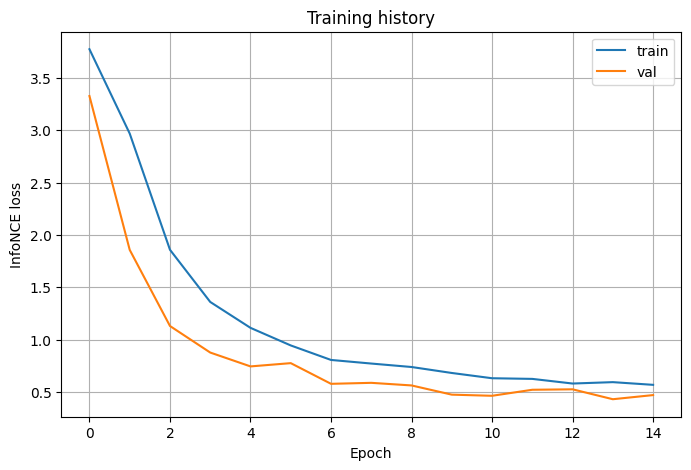

In [68]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("InfoNCE loss")
plt.title("Training history")
plt.legend()
plt.grid(True)
plt.show()

with open(OUTPUT_DIR / "training_history.pkl", "wb") as f:
    pickle.dump(history, f)

## 15. Sanity check: same-client similarity vs different-client similarity

После обучения similarity между двумя срезами одного клиента должна быть выше, чем similarity между срезами разных клиентов.

Это не финальная метрика качества, но хороший быстрый контроль, что contrastive learning работает.

Sanity check:   0%|          | 0/300 [00:00<?, ?it/s]

Mean same-client cosine: 0.8989001549283664
Mean different-client cosine: 0.05020509947401782


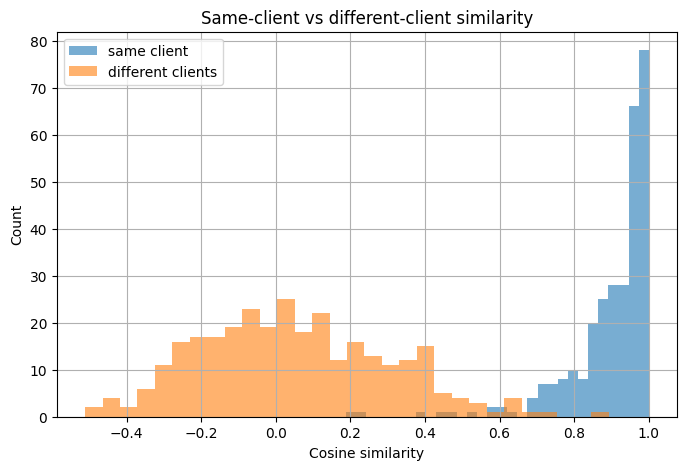

In [69]:
# Загружаем лучший checkpoint
model.load_state_dict(torch.load(OUTPUT_DIR / "best_gru_coles_encoder.pt", map_location=DEVICE))
model.eval()

def encode_slice(slice_dict):
    batch = pad_batch([slice_dict])
    batch = batch_to_device(batch, DEVICE)
    with torch.no_grad():
        z = model(**batch)
    return z[0].cpu().numpy()

same_sims = []
diff_sims = []

sample_clients = random.sample(val_ids, min(300, len(val_ids)))

for client_id in tqdm(sample_clients, desc="Sanity check"):
    seq = client_sequences[client_id]

    s1 = sample_slice(seq)
    s2 = sample_slice(seq)

    z1 = encode_slice(s1)
    z2 = encode_slice(s2)
    same_sims.append(float(np.dot(z1, z2)))

    other_id = random.choice([x for x in val_ids if x != client_id])
    s_other = sample_slice(client_sequences[other_id])
    z_other = encode_slice(s_other)
    diff_sims.append(float(np.dot(z1, z_other)))

print("Mean same-client cosine:", np.mean(same_sims))
print("Mean different-client cosine:", np.mean(diff_sims))

plt.figure(figsize=(8, 5))
plt.hist(same_sims, alpha=0.6, bins=30, label="same client")
plt.hist(diff_sims, alpha=0.6, bins=30, label="different clients")
plt.xlabel("Cosine similarity")
plt.ylabel("Count")
plt.title("Same-client vs different-client similarity")
plt.legend()
plt.grid(True)
plt.show()

## 16. Получение финальных client embeddings

Теперь прогоняем **полную историю каждого клиента** через обученный encoder.

Для каждого клиента получаем:

```python
client_id → embedding vector of size CLIENT_EMB_DIM
```

In [70]:
def encode_full_sequence(sequence):
    # sequence уже ограничена MAX_FULL_SEQ_LEN при сборке client_sequences
    batch = pad_batch([sequence])
    batch = batch_to_device(batch, DEVICE)

    model.eval()
    with torch.no_grad():
        z = model(**batch)

    return z[0].cpu().numpy()


all_client_ids = list(client_sequences.keys())
all_embeddings = []

for client_id in tqdm(all_client_ids, desc="Encoding full client sequences"):
    z = encode_full_sequence(client_sequences[client_id])
    all_embeddings.append(z)

all_embeddings = np.vstack(all_embeddings)

print("Embeddings shape:", all_embeddings.shape)

Encoding full client sequences:   0%|          | 0/4225 [00:00<?, ?it/s]

Embeddings shape: (4225, 128)


## 17. Сохранение эмбеддингов

Сохраняем в нескольких форматах:
- `.npy` — удобно для дальнейшего обучения adapter;
- `.csv` — удобно для просмотра и объединения с таблицами;
- `.pkl` — словарь `client_id -> embedding`.

In [71]:
np.save(OUTPUT_DIR / "client_ids.npy", np.array(all_client_ids, dtype=object))
np.save(OUTPUT_DIR / "client_embeddings.npy", all_embeddings)

client_embeddings_dict = {
    client_id: emb for client_id, emb in zip(all_client_ids, all_embeddings)
}

with open(OUTPUT_DIR / "client_embeddings_dict.pkl", "wb") as f:
    pickle.dump(client_embeddings_dict, f)

emb_df = pd.DataFrame(all_embeddings, columns=[f"emb_{i}" for i in range(all_embeddings.shape[1])])
emb_df.insert(0, CLIENT_COL, all_client_ids)
emb_df.to_csv(OUTPUT_DIR / "client_embeddings.csv", index=False)

print("Saved files to:", OUTPUT_DIR.resolve())
display(emb_df.head())

Saved files to: /content/outputs_embeddings


,cl_id,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127
0,1,-0.090633,-0.110058,0.082819,0.069689,0.004469,-0.118510,0.006002,0.075366,-0.261989,...,0.151721,0.000093,0.098524,-0.167440,-0.057761,-0.190116,0.108227,0.113637,0.041323,-0.049564
1,5,-0.153143,-0.148642,0.035925,0.016191,0.033432,-0.121803,0.033676,-0.002335,-0.178569,...,0.106154,0.025402,0.109769,-0.088950,0.008404,-0.145682,0.042650,0.055799,0.104410,0.048666
2,9,-0.019956,0.002975,0.048143,-0.045387,-0.000634,-0.139534,0.098236,0.038643,-0.029560,...,-0.047351,-0.125565,0.065454,-0.155124,0.000295,0.008246,0.016225,0.014337,0.120207,-0.083786
3,10,-0.107411,-0.050700,0.095111,-0.018756,0.088822,-0.114169,-0.012407,0.038701,-0.107920,...,-0.042606,0.001604,0.077634,-0.054942,0.031432,-0.051014,-0.018825,-0.070956,0.139578,0.015323
4,11,-0.083728,-0.082389,0.018805,0.053381,0.034617,-0.106847,-0.117075,0.063418,-0.286952,...,0.095101,0.080280,0.135540,-0.107477,0.026781,-0.185572,0.115864,0.072907,0.046178,-0.005210


In [72]:
!zip -r outputs_embeddings.zip outputs_embeddings

  adding: outputs_embeddings/ (stored 0%)
  adding: outputs_embeddings/best_gru_coles_encoder.pt (deflated 9%)
  adding: outputs_embeddings/training_history.pkl (deflated 16%)
  adding: outputs_embeddings/num_scaler.pkl (deflated 23%)
  adding: outputs_embeddings/client_embeddings.csv (deflated 60%)
  adding: outputs_embeddings/client_ids.npy (deflated 26%)
  adding: outputs_embeddings/client_embeddings_dict.pkl (deflated 12%)
  adding: outputs_embeddings/client_sequences.pkl (deflated 88%)
  adding: outputs_embeddings/client_embeddings.npy (deflated 7%)
  adding: outputs_embeddings/split_ids.pkl (deflated 26%)


In [73]:
from google.colab import files
files.download("outputs_embeddings.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
!zip -r outputs_descriptions.zip outputs_descriptions

from google.colab import files
files.download("outputs_descriptions.zip")

  adding: outputs_descriptions/ (stored 0%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 18. Optional baseline: PCA embeddings из агрегированных признаков

Это не основной CoLES-embedding, но полезный baseline.

Здесь создаём простые client-level признаки и сжимаем их через PCA.
Потом можно сравнить:
- PCA aggregated embeddings;
- GRU contrastive embeddings;
- text-summary embeddings.

In [33]:
# Простые агрегированные признаки
agg_features = df.groupby(CLIENT_COL).agg(
    tx_count=(AMOUNT_COL, "count"),
    total_abs_amount=(AMOUNT_COL, lambda x: np.abs(x).sum()),
    mean_abs_amount=(AMOUNT_COL, lambda x: np.abs(x).mean()),
    std_abs_amount=(AMOUNT_COL, lambda x: np.abs(x).std()),
    active_days=(DATETIME_COL, lambda x: x.dt.date.nunique()),
    category_nunique=(CATEGORY_COL, "nunique"),
).reset_index()

agg_features["std_abs_amount"] = agg_features["std_abs_amount"].fillna(0)
agg_features["tx_per_active_day"] = agg_features["tx_count"] / agg_features["active_days"].clip(lower=1)

feature_cols = [c for c in agg_features.columns if c != CLIENT_COL]

agg_scaler = StandardScaler()
X_agg = agg_scaler.fit_transform(agg_features[feature_cols])

n_components = min(32, X_agg.shape[1])
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_agg)

pca_df = pd.DataFrame(X_pca, columns=[f"pca_emb_{i}" for i in range(X_pca.shape[1])])
pca_df.insert(0, CLIENT_COL, agg_features[CLIENT_COL].values)

pca_df.to_csv(OUTPUT_DIR / "client_pca_agg_embeddings.csv", index=False)

with open(OUTPUT_DIR / "agg_scaler_pca.pkl", "wb") as f:
    pickle.dump({"scaler": agg_scaler, "pca": pca, "feature_cols": feature_cols}, f)

print("PCA embeddings shape:", X_pca.shape)
display(pca_df.head())

PCA embeddings shape: (4225, 7)


,cl_id,pca_emb_0,pca_emb_1,pca_emb_2,pca_emb_3,pca_emb_4,pca_emb_5,pca_emb_6
0,1,-0.323581,-0.158707,-0.656076,0.150809,-0.055642,-0.166729,-0.061601
1,5,-1.261756,0.873446,-1.036836,0.618141,0.214720,-0.321810,-0.043367
2,9,2.031364,-1.088568,-0.769110,-0.853471,-0.077093,0.030483,-0.090035
3,10,-4.039308,3.910020,2.030419,-0.934278,0.059971,1.327363,-0.026863
4,11,-2.190474,1.647540,-0.012267,0.781094,0.264801,0.094805,-0.146371


## 19. Что дальше

На выходе этого ноутбука у тебя есть:

```text
outputs_embeddings/
    best_gru_coles_encoder.pt
    client_embeddings.npy
    client_ids.npy
    client_embeddings.csv
    client_embeddings_dict.pkl
    client_sequences.pkl
    split_ids.pkl
    client_pca_agg_embeddings.csv
```

Следующий этап исследования:

```text
client_embeddings
        ↓
LLM-generated reference descriptions
        ↓
adapter: embedding → soft tokens
        ↓
LLM explanation
```

Также полезно сделать:
1. downstream prediction на эмбеддингах, если есть target;
2. probing: проверить, кодируют ли embeddings понятные признаки вроде high_cash_share, high_spending, stable_activity;
3. UMAP/t-SNE визуализацию embeddings.

## Features + clients' descriptions

In [11]:
import pandas as pd
import numpy as np
import pickle
import json
from pathlib import Path

CLIENT_COL = "cl_id"
DATETIME_COL = "TRDATETIME"
AMOUNT_COL = "amount"
CATEGORY_COL = "MCC"
TYPE_COL = "trx_category"
CURRENCY_COL = "currency"

DATA_PATH = "train.csv"

EMB_OUTPUT_DIR = Path("outputs_embeddings")
DESC_DIR = Path("outputs_descriptions")
DESC_DIR.mkdir(exist_ok=True, parents=True)

df = train

df[DATETIME_COL] = pd.to_datetime(
    df[DATETIME_COL],
    format="%d%b%y:%H:%M:%S",
    errors="coerce"
)

required_cols = [
    CLIENT_COL,
    DATETIME_COL,
    AMOUNT_COL,
    CATEGORY_COL,
    TYPE_COL
]

df = df.dropna(subset=required_cols).copy()

df[CATEGORY_COL] = df[CATEGORY_COL].astype(str)
df[TYPE_COL] = df[TYPE_COL].astype(str)

# Валюту не используем для dropna — пропуски превращаем в отдельную категорию
df[CURRENCY_COL] = df[CURRENCY_COL].fillna("UNKNOWN").astype(str)

print(df.shape)
display(df.head())

(490513, 10)


,PERIOD,cl_id,MCC,channel_type,currency,TRDATETIME,amount,trx_category,target_flag,target_sum
0,01/10/2017,0,5200,NaN,810,2017-10-21 00:00:00,5023.0,POS,0,0.0
1,01/10/2017,0,6011,NaN,810,2017-10-12 12:24:07,20000.0,DEPOSIT,0,0.0
2,01/12/2017,0,5921,NaN,810,2017-12-05 00:00:00,767.0,POS,0,0.0
3,01/10/2017,0,5411,NaN,810,2017-10-21 00:00:00,2031.0,POS,0,0.0
4,01/10/2017,0,6012,NaN,810,2017-10-24 13:14:24,36562.0,C2C_OUT,0,0.0


In [12]:
df["amount_abs"] = df[AMOUNT_COL].abs()

df["is_pos"] = (df[TYPE_COL] == "POS").astype(int)

df["is_cash_withdrawal"] = (
    df[TYPE_COL]
    .str.contains("WD_ATM", case=False, na=False)
    .astype(int)
)

df["is_deposit"] = (
    df[TYPE_COL]
    .str.contains("DEPOSIT", case=False, na=False)
    .astype(int)
)

df["is_c2c"] = (
    df[TYPE_COL]
    .str.contains("C2C", case=False, na=False)
    .astype(int)
)

df["date"] = df[DATETIME_COL].dt.date
df["hour"] = df[DATETIME_COL].dt.hour
df["day_of_week"] = df[DATETIME_COL].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

display(df[[CLIENT_COL, DATETIME_COL, AMOUNT_COL, CATEGORY_COL, TYPE_COL, CURRENCY_COL]].head())

,cl_id,TRDATETIME,amount,MCC,trx_category,currency
0,0,2017-10-21 00:00:00,5023.0,5200,POS,810
1,0,2017-10-12 12:24:07,20000.0,6011,DEPOSIT,810
2,0,2017-12-05 00:00:00,767.0,5921,POS,810
3,0,2017-10-21 00:00:00,2031.0,5411,POS,810
4,0,2017-10-24 13:14:24,36562.0,6012,C2C_OUT,810


In [13]:
client_stats = df.groupby(CLIENT_COL).agg(
    tx_count=(AMOUNT_COL, "count"),
    total_amount=("amount_abs", "sum"),
    mean_amount=("amount_abs", "mean"),
    median_amount=("amount_abs", "median"),
    std_amount=("amount_abs", "std"),

    active_days=("date", "nunique"),
    unique_mcc=(CATEGORY_COL, "nunique"),
    unique_trx_categories=(TYPE_COL, "nunique"),
    unique_currencies=(CURRENCY_COL, "nunique"),

    pos_share=("is_pos", "mean"),
    cash_withdrawal_share=("is_cash_withdrawal", "mean"),
    deposit_share=("is_deposit", "mean"),
    c2c_share=("is_c2c", "mean"),
    weekend_share=("is_weekend", "mean"),
).reset_index()

client_stats["std_amount"] = client_stats["std_amount"].fillna(0)

client_stats["tx_per_active_day"] = (
    client_stats["tx_count"] / client_stats["active_days"].clip(lower=1)
)

display(client_stats.head())

,cl_id,tx_count,total_amount,mean_amount,median_amount,std_amount,active_days,unique_mcc,unique_trx_categories,unique_currencies,pos_share,cash_withdrawal_share,deposit_share,c2c_share,weekend_share,tx_per_active_day
0,0,5,64383.00,12876.600000,5023.00,15310.857954,4,5,3,1,0.600000,0.000000,0.200000,0.200000,0.400000,1.250000
1,1,104,267578.04,2572.865769,300.00,9941.338142,52,23,3,2,0.971154,0.009615,0.019231,0.000000,0.211538,2.000000
2,5,142,546369.13,3847.669930,1399.02,7426.434312,68,34,7,3,0.781690,0.126761,0.028169,0.056338,0.281690,2.088235
3,9,39,849315.09,21777.310000,100.00,39788.005862,32,5,5,1,0.743590,0.153846,0.025641,0.076923,0.230769,1.218750
4,10,463,1124343.99,2428.388747,325.00,10934.455020,87,36,7,1,0.807775,0.090713,0.051836,0.043197,0.380130,5.321839


In [14]:
def top_values_for_client(group, col, top_n=3):
    counts = group[col].value_counts(normalize=True).head(top_n)
    return [
        {"value": str(idx), "share": float(val)}
        for idx, val in counts.items()
    ]


top_mcc = (
    df.groupby(CLIENT_COL)
      .apply(lambda g: top_values_for_client(g, CATEGORY_COL, top_n=3))
      .reset_index(name="top_mcc")
)

top_trx = (
    df.groupby(CLIENT_COL)
      .apply(lambda g: top_values_for_client(g, TYPE_COL, top_n=3))
      .reset_index(name="top_trx_categories")
)

top_currency = (
    df.groupby(CLIENT_COL)
      .apply(lambda g: top_values_for_client(g, CURRENCY_COL, top_n=3))
      .reset_index(name="top_currencies")
)

client_stats = client_stats.merge(top_mcc, on=CLIENT_COL, how="left")
client_stats = client_stats.merge(top_trx, on=CLIENT_COL, how="left")
client_stats = client_stats.merge(top_currency, on=CLIENT_COL, how="left")

display(client_stats[[CLIENT_COL, "top_mcc", "top_trx_categories", "top_currencies"]].head())

/tmp/ipykernel_1369/935403222.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: top_values_for_client(g, CATEGORY_COL, top_n=3))
/tmp/ipykernel_1369/935403222.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: top_values_for_client(g, TYPE_COL, top_n=3))
/tmp/ipykernel_1369/935403222.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. Th

,cl_id,top_mcc,top_trx_categories,top_currencies
0,0,"[{'value': '5200', 'share': 0.2}, {'value': '6...","[{'value': 'POS', 'share': 0.6}, {'value': 'DE...","[{'value': '810', 'share': 1.0}]"
1,1,"[{'value': '5814', 'share': 0.3942307692307692...","[{'value': 'POS', 'share': 0.9711538461538461}...","[{'value': '810', 'share': 0.6730769230769231}..."
2,5,"[{'value': '5411', 'share': 0.2183098591549295...","[{'value': 'POS', 'share': 0.7816901408450704}...","[{'value': '810', 'share': 0.9577464788732394}..."
3,9,"[{'value': '5999', 'share': 0.6923076923076923...","[{'value': 'POS', 'share': 0.7435897435897436}...","[{'value': '810', 'share': 1.0}]"
4,10,"[{'value': '5411', 'share': 0.2224622030237581...","[{'value': 'POS', 'share': 0.8077753779697624}...","[{'value': '810', 'share': 1.0}]"


In [15]:
if "target_flag" in df.columns:
    client_target = (
        df.groupby(CLIENT_COL)["target_flag"]
          .max()
          .reset_index()
    )
    client_stats = client_stats.merge(client_target, on=CLIENT_COL, how="left")

if "target_sum" in df.columns:
    client_target_sum = (
        df.groupby(CLIENT_COL)["target_sum"]
          .max()
          .reset_index()
    )
    client_stats = client_stats.merge(client_target_sum, on=CLIENT_COL, how="left")

display(client_stats.head())

,cl_id,tx_count,total_amount,mean_amount,median_amount,std_amount,active_days,unique_mcc,unique_trx_categories,unique_currencies,...,cash_withdrawal_share,deposit_share,c2c_share,weekend_share,tx_per_active_day,top_mcc,top_trx_categories,top_currencies,target_flag,target_sum
0,0,5,64383.00,12876.600000,5023.00,15310.857954,4,5,3,1,...,0.000000,0.200000,0.200000,0.400000,1.250000,"[{'value': '5200', 'share': 0.2}, {'value': '6...","[{'value': 'POS', 'share': 0.6}, {'value': 'DE...","[{'value': '810', 'share': 1.0}]",0,0.00
1,1,104,267578.04,2572.865769,300.00,9941.338142,52,23,3,2,...,0.009615,0.019231,0.000000,0.211538,2.000000,"[{'value': '5814', 'share': 0.3942307692307692...","[{'value': 'POS', 'share': 0.9711538461538461}...","[{'value': '810', 'share': 0.6730769230769231}...",0,0.00
2,5,142,546369.13,3847.669930,1399.02,7426.434312,68,34,7,3,...,0.126761,0.028169,0.056338,0.281690,2.088235,"[{'value': '5411', 'share': 0.2183098591549295...","[{'value': 'POS', 'share': 0.7816901408450704}...","[{'value': '810', 'share': 0.9577464788732394}...",1,326211.75
3,9,39,849315.09,21777.310000,100.00,39788.005862,32,5,5,1,...,0.153846,0.025641,0.076923,0.230769,1.218750,"[{'value': '5999', 'share': 0.6923076923076923...","[{'value': 'POS', 'share': 0.7435897435897436}...","[{'value': '810', 'share': 1.0}]",0,0.00
4,10,463,1124343.99,2428.388747,325.00,10934.455020,87,36,7,1,...,0.090713,0.051836,0.043197,0.380130,5.321839,"[{'value': '5411', 'share': 0.2224622030237581...","[{'value': 'POS', 'share': 0.8077753779697624}...","[{'value': '810', 'share': 1.0}]",0,0.00


In [16]:
total_amount_q35 = client_stats["total_amount"].quantile(0.35)
total_amount_q75 = client_stats["total_amount"].quantile(0.75)


def activity_level(row):
    if row["tx_count"] >= 150:
        return "high activity"
    elif row["tx_count"] >= 50:
        return "moderate activity"
    else:
        return "low activity"


def spending_level(row):
    if row["total_amount"] >= total_amount_q75:
        return "high spending"
    elif row["total_amount"] >= total_amount_q35:
        return "moderate spending"
    else:
        return "low spending"


def cash_level(row):
    if row["cash_withdrawal_share"] >= 0.25:
        return "cash-heavy"
    elif row["cash_withdrawal_share"] >= 0.10:
        return "moderate cash usage"
    else:
        return "low cash usage"


def stability_level(row):
    ratio = row["std_amount"] / (row["mean_amount"] + 1e-6)

    if ratio <= 1.0:
        return "stable transaction amounts"
    elif ratio <= 2.0:
        return "moderately variable transaction amounts"
    else:
        return "highly variable transaction amounts"


def currency_behavior(row):
    if row["unique_currencies"] <= 1:
        return "single-currency behavior"
    elif row["unique_currencies"] == 2:
        return "limited multi-currency behavior"
    else:
        return "multi-currency behavior"


client_stats["activity_level"] = client_stats.apply(activity_level, axis=1)
client_stats["spending_level"] = client_stats.apply(spending_level, axis=1)
client_stats["cash_level"] = client_stats.apply(cash_level, axis=1)
client_stats["stability_level"] = client_stats.apply(stability_level, axis=1)
client_stats["currency_behavior"] = client_stats.apply(currency_behavior, axis=1)

display(
    client_stats[
        [
            CLIENT_COL,
            "activity_level",
            "spending_level",
            "cash_level",
            "stability_level",
            "currency_behavior"
        ]
    ].head()
)

,cl_id,activity_level,spending_level,cash_level,stability_level,currency_behavior
0,0,low activity,low spending,low cash usage,moderately variable transaction amounts,single-currency behavior
1,1,moderate activity,low spending,low cash usage,highly variable transaction amounts,limited multi-currency behavior
2,5,moderate activity,moderate spending,moderate cash usage,moderately variable transaction amounts,multi-currency behavior
3,9,low activity,high spending,moderate cash usage,moderately variable transaction amounts,single-currency behavior
4,10,high activity,high spending,low cash usage,highly variable transaction amounts,single-currency behavior


In [17]:
def make_segment_label(row):
    if row["currency_behavior"] == "multi-currency behavior" and row["spending_level"] == "high spending":
        return "High-Value Multi-Currency Client"

    if row["activity_level"] == "high activity" and row["cash_level"] == "low cash usage":
        return "Active Cashless Spender"

    if row["cash_level"] == "cash-heavy":
        return "Cash-Oriented Client"

    if row["spending_level"] == "high spending" and row["activity_level"] in ["high activity", "moderate activity"]:
        return "High-Value Active Client"

    if row["activity_level"] == "low activity":
        return "Low-Activity Client"

    return "Regular Retail Client"


client_stats["segment_label"] = client_stats.apply(make_segment_label, axis=1)

display(client_stats["segment_label"].value_counts())

,count
segment_label,
Regular Retail Client,1644
Low-Activity Client,1207
Active Cashless Spender,880
Cash-Oriented Client,691
High-Value Active Client,451
High-Value Multi-Currency Client,127


In [18]:
def format_top_items(items):
    if not isinstance(items, list) or len(items) == 0:
        return "no dominant categories"

    parts = []
    for item in items:
        value = item["value"]
        share = item["share"]
        parts.append(f"{value} ({share:.1%})")

    return ", ".join(parts)

In [19]:
def make_structured_description(row):
    top_mcc_text = format_top_items(row["top_mcc"])
    top_trx_text = format_top_items(row["top_trx_categories"])
    top_currency_text = format_top_items(row["top_currencies"])

    description = f"""
Behavioral profile:
The client demonstrates {row['activity_level']} across {int(row['active_days'])} active days and {int(row['tx_count'])} transactions.

Spending behavior:
The total transaction amount is approximately {row['total_amount']:.2f}, with an average transaction amount of {row['mean_amount']:.2f}. The spending level is {row['spending_level']}.

Main categories:
The dominant MCC categories are {top_mcc_text}. The main transaction types are {top_trx_text}.

Currency behavior:
The dominant transaction currencies are {top_currency_text}. The client used {int(row['unique_currencies'])} unique currencies, indicating {row['currency_behavior']}.

Cash and transaction type behavior:
The client shows {row['cash_level']}. Cash withdrawals represent {row['cash_withdrawal_share']:.1%} of transactions, POS transactions represent {row['pos_share']:.1%}, deposits represent {row['deposit_share']:.1%}, and C2C operations represent {row['c2c_share']:.1%}.

Stability:
The transaction pattern shows {row['stability_level']}.

Segment:
{row['segment_label']}
""".strip()

    return description


client_stats["structured_reference_description"] = client_stats.apply(
    make_structured_description,
    axis=1
)

pd.set_option("display.max_colwidth", 500)
display(client_stats[[CLIENT_COL, "structured_reference_description"]].head())

,cl_id,structured_reference_description
0,0,"Behavioral profile:\nThe client demonstrates low activity across 4 active days and 5 transactions.\n\nSpending behavior:\nThe total transaction amount is approximately 64383.00, with an average transaction amount of 12876.60. The spending level is low spending.\n\nMain categories:\nThe dominant MCC categories are 5200 (20.0%), 6011 (20.0%), 5921 (20.0%). The main transaction types are POS (60.0%), DEPOSIT (20.0%), C2C_OUT (20.0%).\n\nCurrency behavior:\nThe dominant transaction currencies ar..."
1,1,"Behavioral profile:\nThe client demonstrates moderate activity across 52 active days and 104 transactions.\n\nSpending behavior:\nThe total transaction amount is approximately 267578.04, with an average transaction amount of 2572.87. The spending level is low spending.\n\nMain categories:\nThe dominant MCC categories are 5814 (39.4%), 5812 (18.3%), 5411 (11.5%). The main transaction types are POS (97.1%), DEPOSIT (1.9%), WD_ATM_ROS (1.0%).\n\nCurrency behavior:\nThe dominant transaction curr..."
2,5,"Behavioral profile:\nThe client demonstrates moderate activity across 68 active days and 142 transactions.\n\nSpending behavior:\nThe total transaction amount is approximately 546369.13, with an average transaction amount of 3847.67. The spending level is moderate spending.\n\nMain categories:\nThe dominant MCC categories are 5411 (21.8%), 6011 (15.5%), 5691 (9.2%). The main transaction types are POS (78.2%), WD_ATM_ROS (9.9%), C2C_OUT (5.6%).\n\nCurrency behavior:\nThe dominant transaction ..."
3,9,"Behavioral profile:\nThe client demonstrates low activity across 32 active days and 39 transactions.\n\nSpending behavior:\nThe total transaction amount is approximately 849315.09, with an average transaction amount of 21777.31. The spending level is high spending.\n\nMain categories:\nThe dominant MCC categories are 5999 (69.2%), 6011 (17.9%), 6012 (7.7%). The main transaction types are POS (74.4%), WD_ATM_ROS (12.8%), C2C_IN (7.7%).\n\nCurrency behavior:\nThe dominant transaction currencie..."
4,10,"Behavioral profile:\nThe client demonstrates high activity across 87 active days and 463 transactions.\n\nSpending behavior:\nThe total transaction amount is approximately 1124343.99, with an average transaction amount of 2428.39. The spending level is high spending.\n\nMain categories:\nThe dominant MCC categories are 5411 (22.2%), 5999 (17.5%), 6011 (14.3%). The main transaction types are POS (80.8%), WD_ATM_ROS (8.4%), DEPOSIT (5.2%).\n\nCurrency behavior:\nThe dominant transaction curren..."


In [20]:
def make_risk_description(row):
    risks = []

    if row["cash_withdrawal_share"] >= 0.25:
        risks.append("high share of cash withdrawals")

    if row["std_amount"] / (row["mean_amount"] + 1e-6) >= 2.0:
        risks.append("high variability in transaction amounts")

    if row["active_days"] <= 10:
        risks.append("limited observed activity period")

    if row["unique_mcc"] <= 2:
        risks.append("high concentration in a small number of MCC categories")

    if row["unique_currencies"] >= 3:
        risks.append("multi-currency activity that may require additional monitoring")

    if len(risks) == 0:
        risk_text = (
            "No strong behavioral risk factors are visible from the observed "
            "transaction statistics."
        )
    else:
        risk_text = (
            "Possible behavioral risk factors include: "
            + ", ".join(risks)
            + "."
        )

    return risk_text


client_stats["risk_description"] = client_stats.apply(make_risk_description, axis=1)

display(client_stats[[CLIENT_COL, "risk_description"]].head())

,cl_id,risk_description
0,0,Possible behavioral risk factors include: limited observed activity period.
1,1,Possible behavioral risk factors include: high variability in transaction amounts.
2,5,Possible behavioral risk factors include: multi-currency activity that may require additional monitoring.
3,9,No strong behavioral risk factors are visible from the observed transaction statistics.
4,10,Possible behavioral risk factors include: high variability in transaction amounts.


In [21]:
def make_prompt(task_type):
    if task_type == "profile":
        return "Describe the financial behavior of this client."

    if task_type == "risk":
        return "List possible behavioral risk factors for this client."

    if task_type == "segment":
        return "Assign a behavioral segment to this client and explain it."

    if task_type == "currency":
        return "Describe the currency usage pattern of this client."

    return "Describe this client."


records = []

for _, row in client_stats.iterrows():
    cl_id = row[CLIENT_COL]

    records.append({
        "cl_id": int(cl_id),
        "task": "profile",
        "prompt": make_prompt("profile"),
        "target": row["structured_reference_description"]
    })

    records.append({
        "cl_id": int(cl_id),
        "task": "risk",
        "prompt": make_prompt("risk"),
        "target": row["risk_description"]
    })

    records.append({
        "cl_id": int(cl_id),
        "task": "segment",
        "prompt": make_prompt("segment"),
        "target": (
            f"The client belongs to the segment: {row['segment_label']}. "
            f"This is based on {row['activity_level']}, {row['spending_level']}, "
            f"{row['cash_level']}, and {row['currency_behavior']}."
        )
    })

    records.append({
        "cl_id": int(cl_id),
        "task": "currency",
        "prompt": make_prompt("currency"),
        "target": (
            f"The dominant transaction currencies are {format_top_items(row['top_currencies'])}. "
            f"The client used {int(row['unique_currencies'])} unique currencies, "
            f"indicating {row['currency_behavior']}."
        )
    })

print("Number of records:", len(records))
records[0]

Number of records: 20000


{'cl_id': 0,
 'task': 'profile',
 'prompt': 'Describe the financial behavior of this client.',
 'target': 'Behavioral profile:\nThe client demonstrates low activity across 4 active days and 5 transactions.\n\nSpending behavior:\nThe total transaction amount is approximately 64383.00, with an average transaction amount of 12876.60. The spending level is low spending.\n\nMain categories:\nThe dominant MCC categories are 5200 (20.0%), 6011 (20.0%), 5921 (20.0%). The main transaction types are POS (60.0%), DEPOSIT (20.0%), C2C_OUT (20.0%).\n\nCurrency behavior:\nThe dominant transaction currencies are 810 (100.0%). The client used 1 unique currencies, indicating single-currency behavior.\n\nCash and transaction type behavior:\nThe client shows low cash usage. Cash withdrawals represent 0.0% of transactions, POS transactions represent 60.0%, deposits represent 20.0%, and C2C operations represent 20.0%.\n\nStability:\nThe transaction pattern shows moderately variable transaction amounts.\n\n

### LLM-descripions option

In [29]:
pip install langchain

In [49]:
import os
import time
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers.string import StrOutputParser
#from langchain.schema import HumanMessage
from typing import Dict, List, Tuple
import asyncio
from tqdm.auto import tqdm
from langchain_core.messages import SystemMessage, HumanMessage

os.environ['OPENAI_API_KEY'] = 'sk-aT7biUAl8WAMraNRpin6zXU12srm5xQB'
os.environ['OPENAI_API_BASE'] = "https://api.proxyapi.ru/openai/v1"
model_name = "gpt-4o-mini"
llm = ChatOpenAI(model_name=model_name, temperature=0.1)

In [44]:
from pydantic import BaseModel, Field
from langchain_core.messages import SystemMessage, HumanMessage
import json
import time

class ClientDescription(BaseModel):
    behavioral_profile: str = Field(
        description="General behavioral profile of the client."
    )
    spending_behavior: str = Field(
        description="Description of spending amount, frequency, and intensity."
    )
    transaction_type_behavior: str = Field(
        description="Description of POS, cash withdrawals, deposits, C2C or other transaction type patterns."
    )
    currency_behavior: str = Field(
        description="Description of currency usage and multi-currency behavior."
    )
    risk_factors: str = Field(
        description="Grounded behavioral risk factors visible from the statistics. No unsupported claims."
    )
    segment_explanation: str = Field(
        description="Explanation of the assigned behavioral segment."
    )

structured_llm = llm.with_structured_output(ClientDescription)


In [45]:
def format_structured_llm_description(parsed: ClientDescription):
    description = f"""
Behavioral profile:
{parsed.behavioral_profile}

Spending behavior:
{parsed.spending_behavior}

Transaction type behavior:
{parsed.transaction_type_behavior}

Currency behavior:
{parsed.currency_behavior}

Risk factors:
{parsed.risk_factors}

Segment explanation:
{parsed.segment_explanation}
""".strip()

    return description

In [46]:
def generate_gpt_reference_description(row, max_retries=3, sleep_sec=2):
    stats = format_client_stats_for_llm(row)

    system_prompt = """
You are a financial behavior analyst.
Your task is to write grounded, factual behavioral descriptions of bank clients based only on provided aggregated transaction statistics.

Rules:
- Do not invent facts that are not present in the statistics.
- Do not mention creditworthiness unless it is directly supported by the provided statistics.
- Do not use sensitive demographic assumptions.
- Do not provide financial advice.
- Keep the text concise and analytical.
- Use exact numbers when useful.
""".strip()

    user_prompt = f"""
Create a client behavioral profile from the following aggregated statistics.

Statistics:
{json.dumps(stats, ensure_ascii=False, indent=2)}

Return a structured answer with these fields:
- behavioral_profile
- spending_behavior
- transaction_type_behavior
- currency_behavior
- risk_factors
- segment_explanation
""".strip()

    for attempt in range(max_retries):
        try:
            messages = [
                SystemMessage(content=system_prompt),
                HumanMessage(content=user_prompt),
            ]

            parsed = structured_llm.invoke(messages)
            return format_structured_llm_description(parsed)

        except Exception as e:
            print(f"Attempt {attempt + 1} failed for client {row[CLIENT_COL]}: {e}")
            time.sleep(sleep_sec)

    return None

In [39]:
def generate_hybrid_reference_description(row, max_retries=3, sleep_sec=2):
    stats = format_client_stats_for_llm(row)
    rule_based_text = row["structured_reference_description"]

    system_prompt = """
You are a financial behavior analyst.
Your task is to rewrite deterministic rule-based client descriptions into clearer analyst-style explanations.

Rules:
- Preserve all factual content from the original description.
- Do not add facts that are not present in the statistics or original description.
- Do not remove important behavioral signals.
- Do not make demographic, health, or sensitive attribute assumptions.
- Do not provide financial advice.
- Keep the result structured and concise.
""".strip()

    user_prompt = f"""
Rewrite the following rule-based description into a more natural analyst-style description.

Aggregated statistics:
{json.dumps(stats, ensure_ascii=False, indent=2)}

Original rule-based description:
{rule_based_text}

Return a structured answer with these fields:
- behavioral_profile
- spending_behavior
- transaction_type_behavior
- currency_behavior
- risk_factors
- segment_explanation
""".strip()

    for attempt in range(max_retries):
        try:
            messages = [
                SystemMessage(content=system_prompt),
                HumanMessage(content=user_prompt),
            ]

            parsed = structured_llm.invoke(messages)
            return format_structured_llm_description(parsed)

        except Exception as e:
            print(f"Attempt {attempt + 1} failed for client {row[CLIENT_COL]}: {e}")
            time.sleep(sleep_sec)

    return None

In [47]:
sample_row = client_stats.sample(1, random_state=42).iloc[0]

gpt_text = generate_gpt_reference_description(sample_row)
hybrid_text = generate_hybrid_reference_description(sample_row)

print("=" * 100)
print("RULE-BASED:")
print(sample_row["structured_reference_description"])

print("=" * 100)
print("GPT:")
print(gpt_text)

print("=" * 100)
print("HYBRID:")
print(hybrid_text)

RULE-BASED:
Behavioral profile:
The client demonstrates moderate activity across 52 active days and 126 transactions.

Spending behavior:
The total transaction amount is approximately 657634.24, with an average transaction amount of 5219.32. The spending level is high spending.

Main categories:
The dominant MCC categories are 5499 (43.7%), 5411 (21.4%), 6011 (11.9%). The main transaction types are POS (84.9%), WD_ATM_ROS (11.1%), C2C_OUT (2.4%).

Currency behavior:
The dominant transaction currencies are 810 (100.0%). The client used 1 unique currencies, indicating single-currency behavior.

Cash and transaction type behavior:
The client shows moderate cash usage. Cash withdrawals represent 11.9% of transactions, POS transactions represent 84.9%, deposits represent 0.0%, and C2C operations represent 3.2%.

Stability:
The transaction pattern shows highly variable transaction amounts.

Segment:
High-Value Active Client
GPT:
Behavioral profile:
Client 3030 shows moderate activity (126 tr

In [41]:
client_stats["gpt_reference_description"] = None
client_stats["hybrid_reference_description"] = None

In [42]:
SAVE_EVERY = 25
CHECKPOINT_PATH = DESC_DIR / "client_stats_with_gpt_hybrid_checkpoint.csv"

for i, row in tqdm(client_stats.iterrows(), total=len(client_stats)):
    if pd.isna(client_stats.at[i, "gpt_reference_description"]):
        client_stats.at[i, "gpt_reference_description"] = generate_gpt_reference_description(row)

    if pd.isna(client_stats.at[i, "hybrid_reference_description"]):
        client_stats.at[i, "hybrid_reference_description"] = generate_hybrid_reference_description(row)

    if (i + 1) % SAVE_EVERY == 0:
        client_stats.to_csv(CHECKPOINT_PATH, index=False)
        print(f"Saved checkpoint at row {i + 1}")

client_stats.to_csv(CHECKPOINT_PATH, index=False)

  0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [22]:
with open(EMB_OUTPUT_DIR / "split_ids.pkl", "rb") as f:
    split_ids = pickle.load(f)

train_ids = set(map(int, split_ids["train"]))
val_ids = set(map(int, split_ids["val"]))
test_ids = set(map(int, split_ids["test"]))

train_records = [r for r in records if int(r["cl_id"]) in train_ids]
val_records = [r for r in records if int(r["cl_id"]) in val_ids]
test_records = [r for r in records if int(r["cl_id"]) in test_ids]

print("Train records:", len(train_records))
print("Val records:", len(val_records))
print("Test records:", len(test_records))

FileNotFoundError: [Errno 2] No such file or directory: 'outputs_embeddings/split_ids.pkl'

In [ ]:
client_stats.to_csv(
    DESC_DIR / "client_behavioral_stats_descriptions.csv",
    index=False
)

def save_jsonl(records, path):
    with open(path, "w", encoding="utf-8") as f:
        for r in records:
            f.write(json.dumps(r, ensure_ascii=False) + "\n")


save_jsonl(train_records, DESC_DIR / "adapter_train.jsonl")
save_jsonl(val_records, DESC_DIR / "adapter_val.jsonl")
save_jsonl(test_records, DESC_DIR / "adapter_test.jsonl")

print("Saved to:", DESC_DIR.resolve())